In [ ]:
#Furniture Profitability Analysis

##STEP 1: importing data.
import pandas as pd

In [ ]:
df = pd.read_csv("../data/Superstore.csv", encoding="latin1")
df.head()

###Python encoding="utf-8", and this field is encoded by: "latin1"

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
##Step 2: Columns Overview:
df.shape

(9994, 21)

In [ ]:
##Step 3: MISSING VALUES CHECK:

df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

In [34]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Shipping Days    0
dtype: int64

The dataset does not contain missing values. So, cleaning related to null values was not required.

In [ ]:
##Step 4: DATA TYPES:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [16]:
type(df["Order Date"][0])

str

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

###This is the analyst for debugging to make it look in the format M-D-Y, because this was the ValueError popping up. For the solution I converted datetime using dayfirst=True to enable time-based analysis.
###this is de Dtype format for dates: datetime64[us]. wich is demostrated below:

In [21]:
type(df["Order Date"][0])

pandas.Timestamp

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [ ]:
I noticed the following: identified a data type issue, understood the cause, fixed a regional date format problem and Converted to proper datetime.

In [24]:
df["Year"] = df["Order Date"].dt.year

In [25]:
df["Month"] = df["Order Date"].dt.month


In [26]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [ ]:
##Step 5: Analizing Profit by Categories:

profit_by_category = df.groupby("Category")["Profit"].sum()

print(profit_by_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [ ]:
###Organizing them by descending top profit on the top.
profit_by_category = profit_by_category.sort_values(ascending=False)

print(profit_by_category)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [ ]:
This means that Technology is the category that generates the most profit for the company, with a total of $145,454.94, which makes it important to analyze and invest more in this market for optimization. It is followed by Office Supplies, which generates $122,490.80 and is also performing well. Lastly, the category that needs additional support or assistance is Furniture, generating the lowest profit at $18,451.27. Strategies such as discounts or marketing efforts can help with optimization in sales, increase attractiveness and generate higher profit. However, before drawing any final conclusions, its important understand the overall situation of the company.

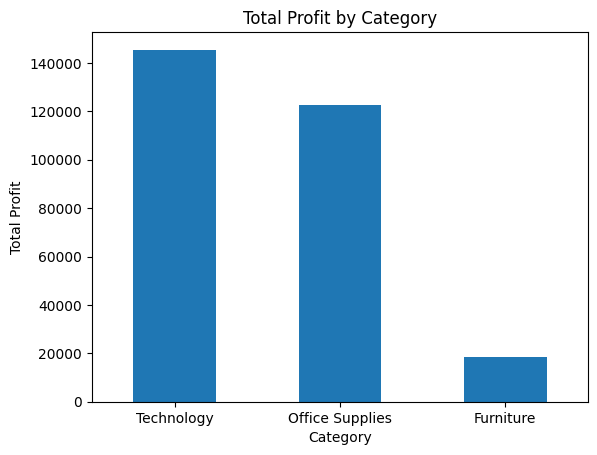

In [ ]:
import matplotlib.pyplot as plt

### Getting the charts for analysis:
plt.figure()
profit_by_category.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.show()

In [ ]:
The clearly dominant category is Technology. However, Furniture performs  significantly lower compared to the rest, with a gap of 100,000 in profit between Furniture and Office Supplies. The large difference highlights the imbalance, which may require further analysis to better understand the underlying causes.


In [ ]:
##Total revenue per category:

sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

sales_by_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

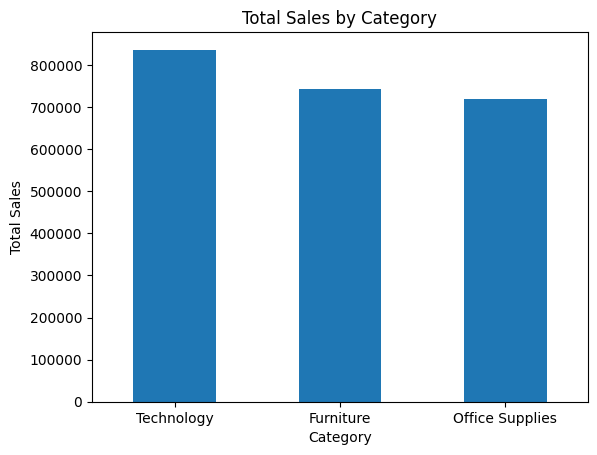

In [33]:
import matplotlib.pyplot as plt

plt.figure()
sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

In [ ]:
The highest sales come from the Technology category, totaling $836,154.03. This indicates that customers are more attracted to this segment. Therefore, the company should find ways to make the Office Supplies and Furniture categories more appealing when customers are shopping for Technology products. Identifying additional customer needs could help increase cross-selling opportunities. However, Furniture and Office Supplies are relatively close in total sales. It is worth noting, that Technology is highest selling and profit is a strong overall performer.

Furniture sales are relatively high, however  profitability remains low. This may indicate low margins on selling prices or the company is providing heavy discounts.

In [ ]:
##Calculate Average Discount by Category

avg_discount_by_category = df.groupby("Category")["Discount"].mean().sort_values(ascending=False)

avg_discount_by_category

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

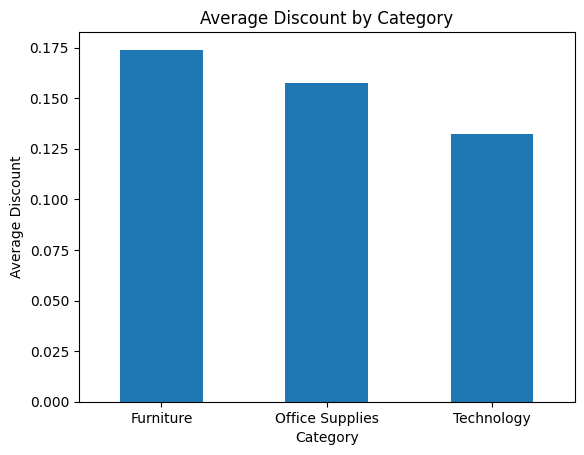

In [38]:
import matplotlib.pyplot as plt

plt.figure()
avg_discount_by_category.plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.xticks(rotation=0)

plt.show()

In [ ]:
ANALYSIS: Based on the graph and the average discount per category, we can observe that the discount rates are 17.39% for Furniture, 15.72% for Office Supplies, and 13.23% for Technology. These percentages suggest that discounts are not significantly hurting margins. The issue may instead be related to cost structure or product pricing. Therefore, it is important to analyze Furniture more closely, as it offers higher discounts while generating lower profit, which requires deeper investigation.

In [ ]:
##Profit Margin (%) by Category:
df["Profit Margin"] = df["Profit"] / df["Sales"]

margin_by_category = df.groupby("Category")["Profit Margin"].mean().sort_values(ascending=False)

margin_by_category

Category
Technology         0.156138
Office Supplies    0.138030
Furniture          0.038784
Name: Profit Margin, dtype: float64

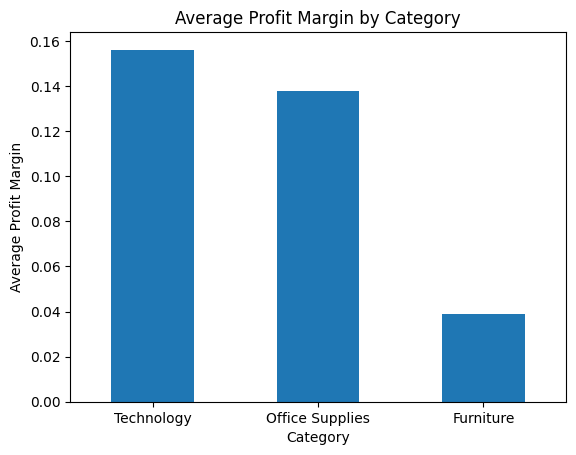

In [40]:
import matplotlib.pyplot as plt

plt.figure()
margin_by_category.plot(kind="bar")

plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit Margin")
plt.xticks(rotation=0)

plt.show()

In [ ]:
ANALYSIS: After this analysis, we can conclude that the issue is not primarily related to discount size, but rather to structural profitability. Technology leads with the highest average profit margin at 15.61%, while Furniture ranks the lowest at 3.87%. This significant difference suggests that the problem may be driven by higher production costs, lower pricing strategies, or inefficient cost structures within the Furniture category.

In [ ]:
##ANSWERING: Which sub-category inside Furniture is hurting profitability the most?

furniture_df = df[df["Category"] == "Furniture"]

furniture_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Shipping Days,Profit Margin
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2013,11,3,0.16
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2013,11,3,0.30
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2012,10,7,-0.40
5,6,CA-2011-115812,2011-06-09,2011-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2011,6,5,0.29
10,11,CA-2011-115812,2011-06-09,2011-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2011,6,5,0.05


In [ ]:
##Isolating only Furniture transactions.

profit_by_sub = (
    furniture_df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_sub

Sub-Category
Chairs         26590.1663
Furnishings    13059.1436
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [3]:
###With this information, the data indicates that Furniture is underperforming. The sub-categories with the most negative impact are Tables (-17,725.48), followed by Bookcases (-3,472.55), which are the main reasons why Furniture is not generating higher profit. While Chairs and Furnishings remain profitable, these sub-categories are contributing positively to overall performance.

###It should be noted that all sub-categories require further analysis. First, production costs should be examined to determine whether it is financially viable to manufacture each item. Second, pricing strategies should be evaluated to ensure profitability at the product level. Lastly, identifying the optimal promotional percentage is a strategic task that requires deeper investigation.

In [4]:
##Profit Comparison by Category

###After analyzing profit and sales by category, I will calculate the profit margin by category as a percentage.

profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_category

NameError: name 'df' is not defined

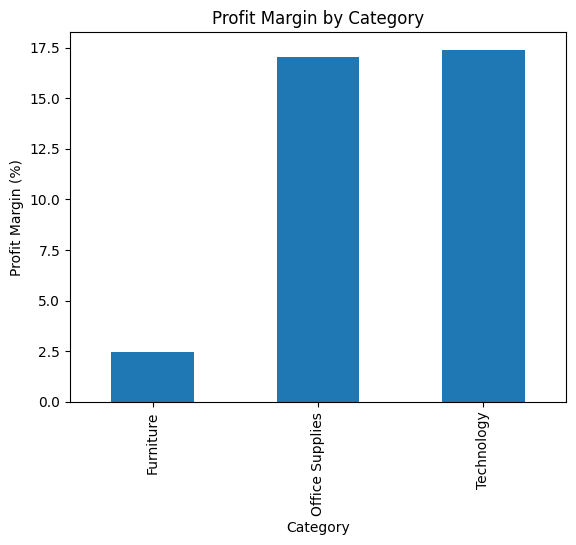

In [ ]:
##Visualization (Profit Margin)

import matplotlib.pyplot as plt

plt.figure()
category_summary["Profit Margin (%)"].sort_values().plot(kind="bar")

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.show()

In [ ]:
After comparing the categories, we can clearly see a big difference in profitability. Technology and Office Supplies both have strong profit margins (17.40% and 17.04%), while Furniture only reaches 2.49%, even though its sales volume is similar. This suggests that the problem in Furniture is not demand. The category is selling. The issue is more likely related to operational efficiency, pricing strategy, production costs, or the level of discounts applied.

These results confirm that the profitability problem is mainly concentrated in the Furniture category, especially in sub-categories like Tables, which we previously identified as one of the main sources of losses.

-----------------------------------------------------------------------------------------------
#Business Recommendations
-----------------------------------------------------------------------------------------------
First thing the company needs to work on is improving profitability within the Furniture category, specially in Tables sub-category. After analyzing the data I concluded that we need to follow steps to make the company profitable in every category.

## Review Costs in Production Process
The main focus should be on Tables (-17,725.48 USD) and Bookcases (-3,472.56 USD), since they generate the most losses. The company could look at redesigning certain elements, reducing production costs, reviewing supplier prices, and optimizing logistics. It’s also worth reviewing the supply chain across all sub-categories, including Chairs and Furnishings, to improve overall category performance.

## Reevaluate Pricing Strategy
Furniture has strong demand, so the company could consider adjusting prices based on market conditions. Running a price elasticity analysis can help determine whether small price adjustments might improve overall profitability without hurting demand.

## Optimize Discount Policy
Discounts shouldn’t be applied to sub-categories that are not profitable. Decisions around discounts should be strategic to increase sales while protecting margins. Establishing a minimum margin threshold for discounted products can prevent future losses.

## Rationalize the Product Portfolio
If certain Tables or Bookcases continue to generate losses even after reviewing costs and prices, they could be discontinued or redesigned. Focus on products that generate profit, like Chairs and Furnishings, and use carefully planned discounts and marketing strategies to boost overall profitability.

### Executive Note
Implementing these measures could significantly increase Furniture’s profitability, narrowing the gap with Technology and Office Supplies, while keeping sales strong.

#CONCLUSIONS

The analysis shows a clear profitability gap across categories. Technology and Office Supplies consistently deliver strong margins, while Furniture lags far behind despite solid sales. Within Furniture, Tables and Bookcases are the main sources of losses, whereas Chairs and Furnishings contribute positively.

Discounts are not the main issue, which points to structural challenges such as high production costs, pricing strategy misalignment, and supply chain inefficiencies. Tackling these areas strategically is critical to boost Furniture’s profitability, optimize the product portfolio, and align all categories with the company’s overall margin objectives.

The analysis should be made deeply, considering that the supply chain is a really important factor. This means suppliers, production costs, employee performance, and pricing are a summary of what the company needs to focus on.

Overall, the results show that Furniture underperformance is not caused by lack of demand, but by structural and operational factors. By addressing these areas, the company can improve Furniture profitability while maintaining strong performance in other categories.
